# Data Loading

In [1]:
import json
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd

In [13]:
def json_to_dic(path):
    with open(path, "r") as f:
        res = json.load(f)
    print(res)
    data = {"KNN":[], "DT":[], "LSVM":[], "KSVM":[], "ANN":[]}
    configs = []
    for exp, r in res.items():
        for model in data.keys():
            if model in r.keys():
                data[model].append(list(r[model].values()))
        s = r["DATASETS"][0].index("hog") + 4
        configs.append(r["DATASETS"][0][s:-4])
    for model in data.keys():
        if model in r.keys():
            data[model] = np.array(data[model])
    print(data)
    print(configs)
    return data, configs

data, configs = json_to_dic("/home/achraf/Research/MLHACK_PAPER/JSONS/experiment_results.json")

{'EXPERIMENT0': {'KNN': {'orig_acc': 0.54322, 'fsgm_acc': 0.30364, 'pgd_acc': 0.36986}, 'DT': {'orig_acc': 0.35226, 'fsgm_acc': 0.2078, 'pgd_acc': 0.2338}, 'LSVM': {'orig_acc': 0.42032, 'fsgm_acc': 0.2742, 'pgd_acc': 0.32458}, 'KSVM': {'orig_acc': 0.74328, 'fsgm_acc': 0.30958, 'pgd_acc': 0.4324}, 'DATE': '2025-11-22 22:35:22.017731', 'DATASETS': ['../Datasets/cifar10-orig-hog-o6-c8-b1.npz', '../Datasets/cifar10-fsgm-hog-eps4-o6-c8-b1.npz', '../Datasets/cifar10-pgd-hog-eps4-o6-c8-b1.npz']}, 'EXPERIMENT1': {'KNN': {'orig_acc': 0.52522, 'fsgm_acc': 0.33638, 'pgd_acc': 0.38594}, 'DT': {'orig_acc': 0.32964, 'fsgm_acc': 0.18476, 'pgd_acc': 0.21062}, 'LSVM': {'orig_acc': 0.42742, 'fsgm_acc': 0.2538, 'pgd_acc': 0.315}, 'KSVM': {'orig_acc': 0.78038, 'fsgm_acc': 0.31908, 'pgd_acc': 0.45378}, 'DATE': '2025-11-22 22:49:44.230055', 'DATASETS': ['../Datasets/cifar10-orig-hog-o6-c6-b1.npz', '../Datasets/cifar10-fsgm-hog-eps4-o6-c6-b1.npz', '../Datasets/cifar10-pgd-hog-eps4-o6-c6-b1.npz']}, 'EXPERIMEN

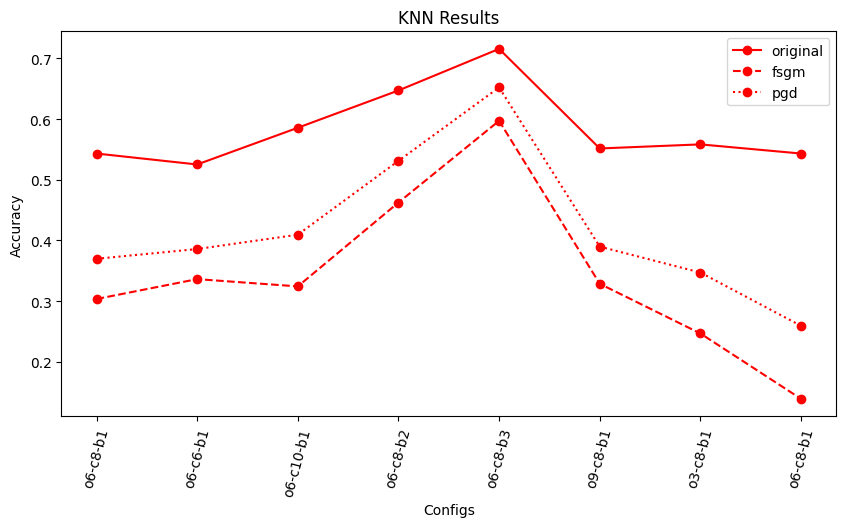

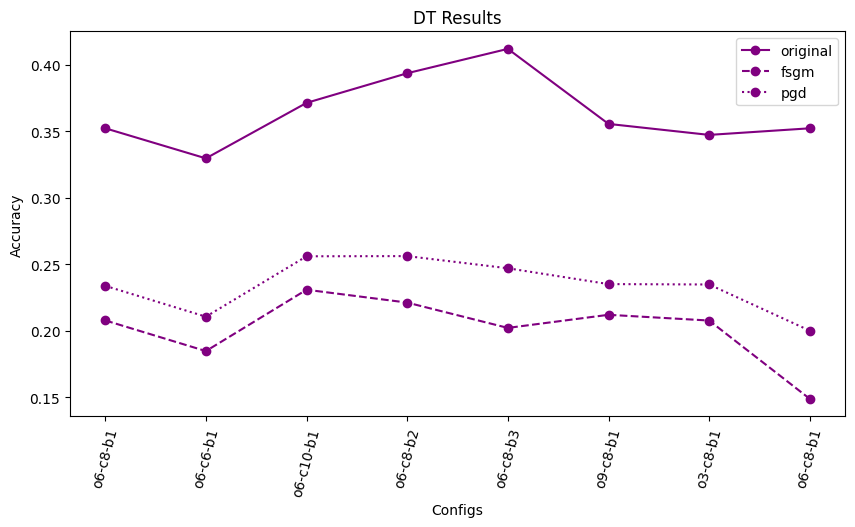

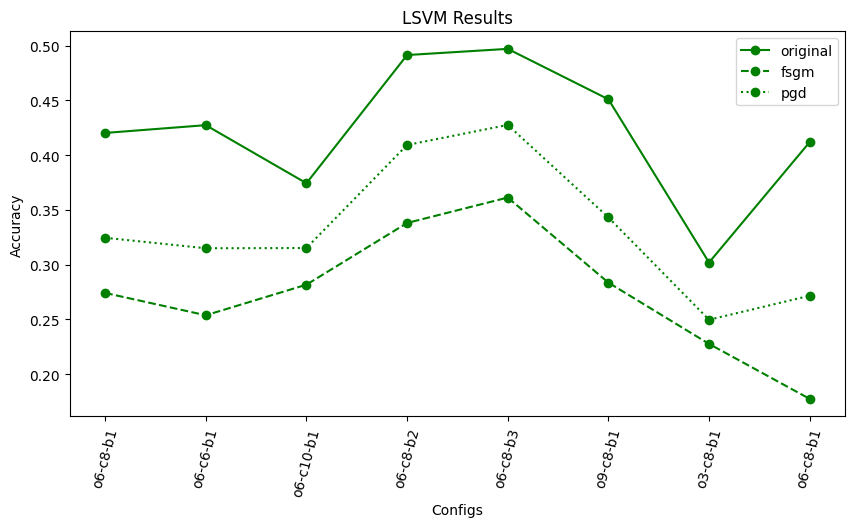

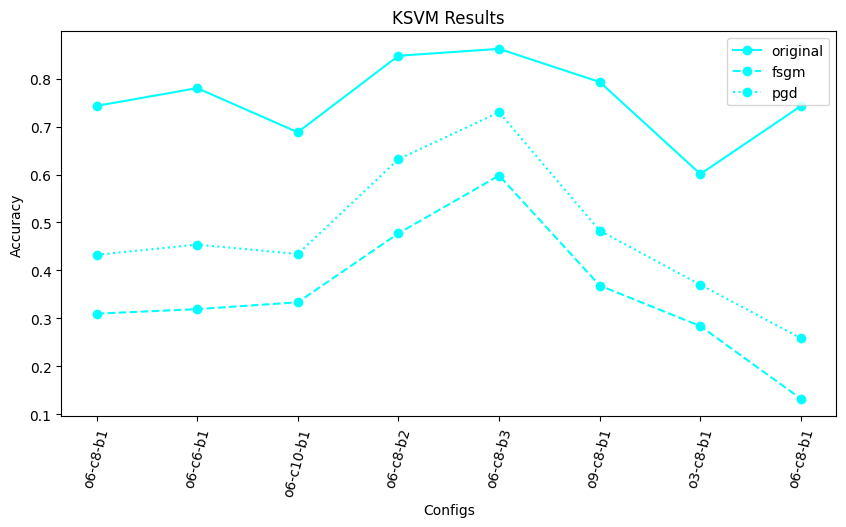

In [3]:
colors = ["r", "purple", "g", "cyan"]
for j, model in enumerate(data.keys()):
    normal = []
    fsgm = []
    pgd = []
    for i in data[model]:
        normal.append(i[0])
        fsgm.append(i[1])
        pgd.append(i[2])

    plt.figure(figsize=(10, 5))
    plt.plot(normal, marker="o", label="original", c=colors[j])
    plt.plot(fsgm, marker="o", label="fsgm" , c=colors[j], linestyle="--")
    plt.plot(pgd, marker="o", label="pgd", c=colors[j], linestyle=":")
    plt.xticks(ticks=np.arange(len(configs)), labels=configs, rotation=75)
    plt.xlabel("Configs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title(f"{model} Results")
    plt.show()


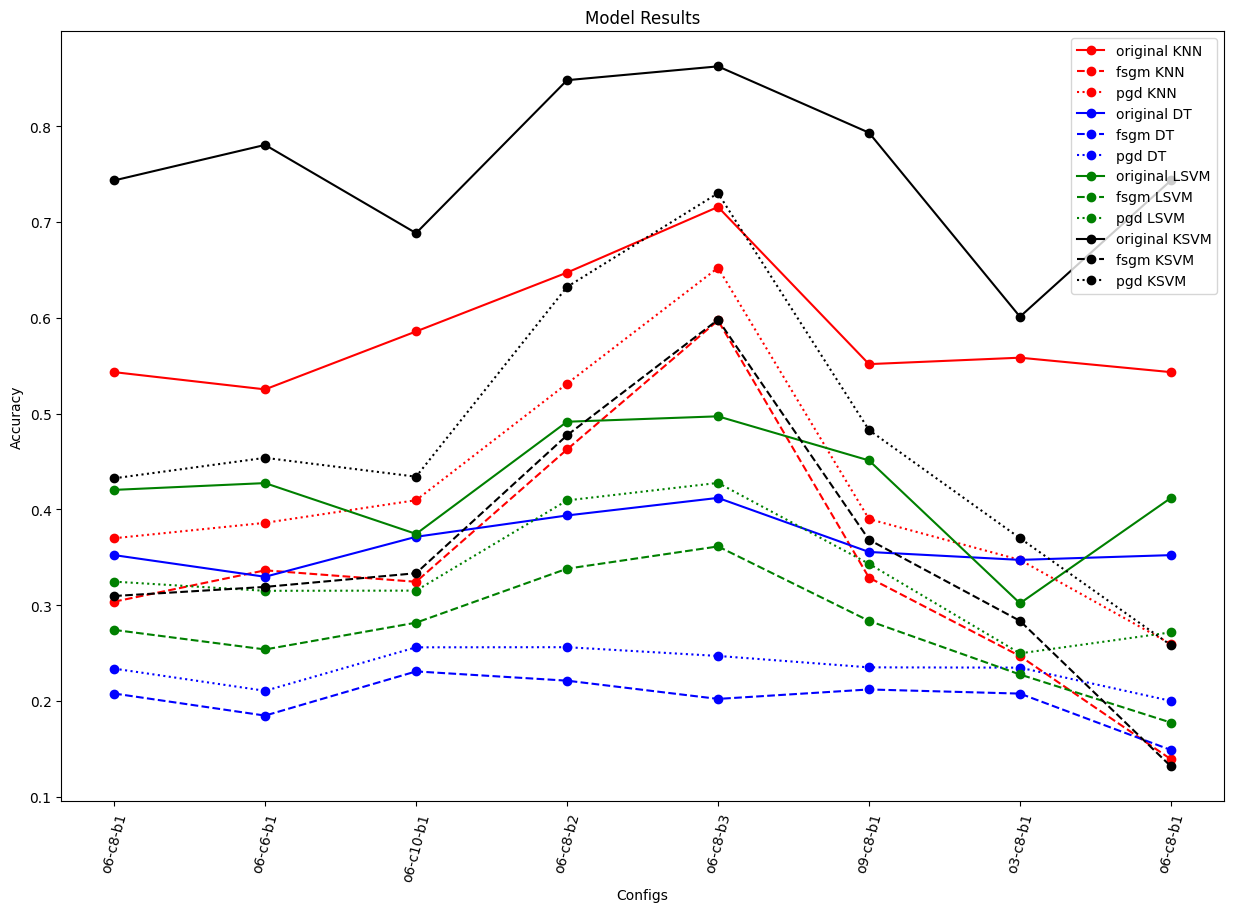

In [4]:
colors = ["r", "blue", "g", "black"]
plt.figure(figsize=(15, 10))
for j, model in enumerate(data.keys()):
    normal = []
    fsgm = []
    pgd = []
    for i in data[model]:
        normal.append(i[0])
        fsgm.append(i[1])
        pgd.append(i[2])

    plt.plot(normal, marker="o", label=f"original {model}", c=colors[j])
    plt.plot(fsgm, marker="o", label=f"fsgm {model}" , c=colors[j], linestyle="--")
    plt.plot(pgd, marker="o", label=f"pgd {model}", c=colors[j], linestyle=":")
plt.xticks(ticks=np.arange(len(configs)), labels=configs, rotation=75)
plt.xlabel("Configs")
plt.ylabel("Accuracy")
plt.legend()
plt.title(f"Model Results")
plt.show()

# Distance from original

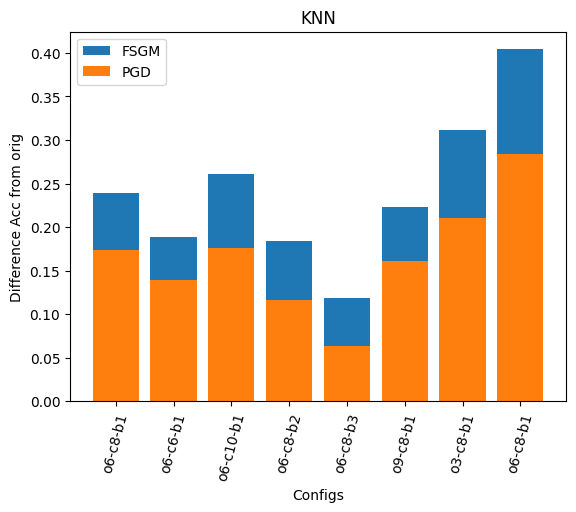

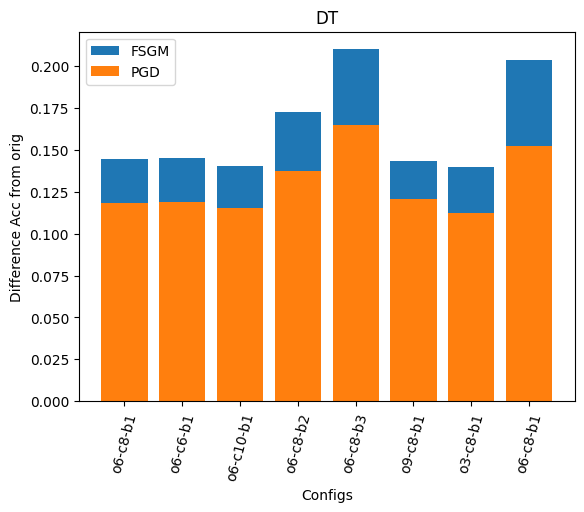

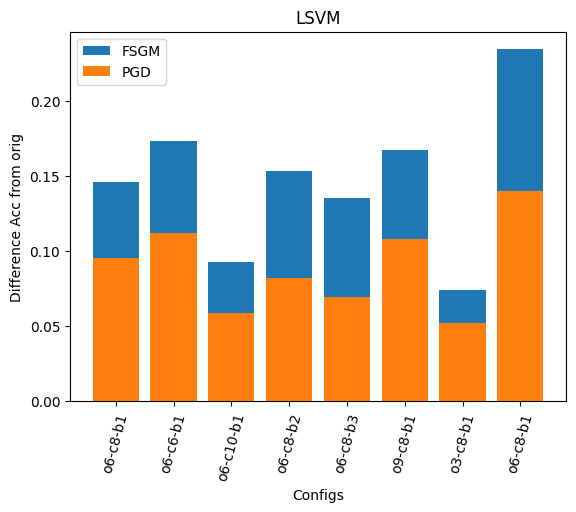

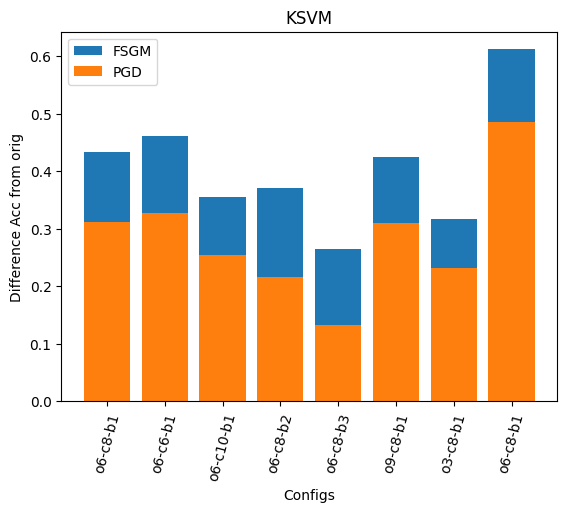

In [5]:
# plt.figure(figsize=(10, 7))
diffs_fsgm = []
for j, model in enumerate(data.keys()):
    diffs_fsgm = data[model][:, 1] - data[model][:, 0]
    diffs_pgd = data[model][:, 2] - data[model][:, 0]
    plt.bar(range(len(diffs_fsgm)), -diffs_fsgm, label="FSGM")
    plt.bar(range(len(diffs_fsgm)), -diffs_pgd, label="PGD")
    plt.xticks(ticks=np.arange(len(configs)), labels=configs, rotation=75)
    plt.xlabel("Configs")
    plt.ylabel("Difference Acc from orig")
    plt.legend()
    plt.title(f"{model}")
    plt.show()
   
    

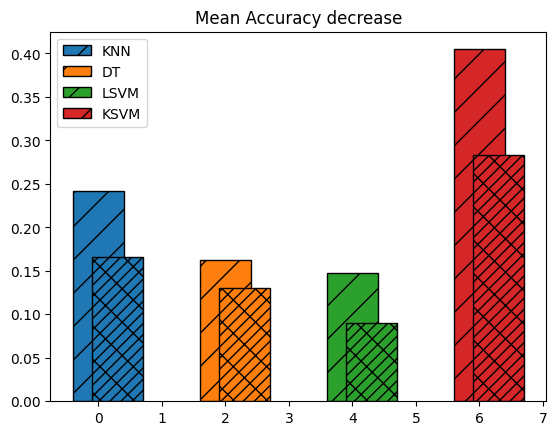

In [6]:
for j, model in enumerate(data.keys()):
    diffs_fsgm = data[model][:, 1] - data[model][:, 0]
    diffs_pgd = data[model][:, 2] - data[model][:, 0]
    plt.bar(
    [2*j, 2*j+0.3],
    [-diffs_fsgm.mean(), -diffs_pgd.mean()],
    hatch=["/", "\\///"],         
    edgecolor="black",         
    label=f"{model}"
    )

plt.title("Mean Accuracy decrease")
plt.legend()
plt.show()

# ANN performance compared to KSVM

In [16]:
ann_data, config = json_to_dic("/home/achraf/Research/MLHACK_PAPER/JSONS/experiment_results_ANN.json")

{'EXPERIMENT0': {'ANN': {'orig_acc': 0.1, 'fsgm_acc': 0.1, 'pgd_acc': 0.1}, 'DATE': '2025-11-28 18:11:24.559380', 'DATASETS': ['../Datasets/cifar10-orig-hog-o6-c8-b1.npz', '../Datasets/cifar10-fsgm-hog-eps4-o6-c8-b1.npz', '../Datasets/cifar10-pgd-hog-eps4-o6-c8-b1.npz']}, 'EXPERIMENT1': {'ANN': {'orig_acc': 0.49196, 'fsgm_acc': 0.30868, 'pgd_acc': 0.35866}, 'DATE': '2025-11-28 18:11:45.090135', 'DATASETS': ['../Datasets/cifar10-orig-hog-o6-c6-b1.npz', '../Datasets/cifar10-fsgm-hog-eps4-o6-c6-b1.npz', '../Datasets/cifar10-pgd-hog-eps4-o6-c6-b1.npz']}, 'EXPERIMENT2': {'ANN': {'orig_acc': 0.47898, 'fsgm_acc': 0.32934, 'pgd_acc': 0.38824}, 'DATE': '2025-11-28 18:12:03.693914', 'DATASETS': ['../Datasets/cifar10-orig-hog-o6-c10-b1.npz', '../Datasets/cifar10-fsgm-hog-eps4-o6-c10-b1.npz', '../Datasets/cifar10-pgd-hog-eps4-o6-c10-b1.npz']}, 'EXPERIMENT3': {'ANN': {'orig_acc': 0.61154, 'fsgm_acc': 0.40044, 'pgd_acc': 0.48202}, 'DATE': '2025-11-28 18:12:27.500036', 'DATASETS': ['../Datasets/cifar

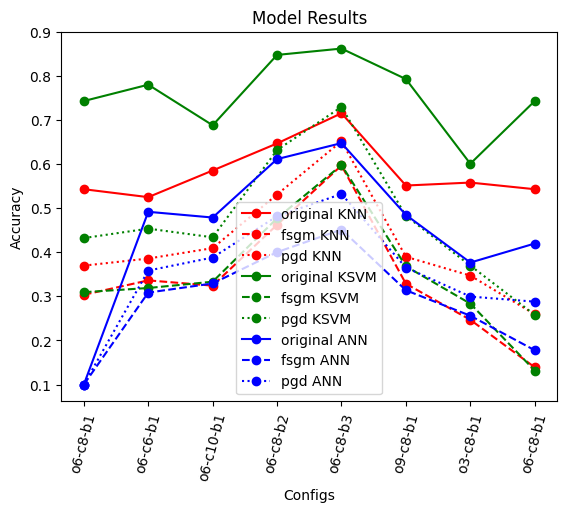

In [22]:
normal = []
fsgm = []
pgd = []

model = "KNN"
for i in data["KNN"]:
    normal.append(i[0])
    fsgm.append(i[1])
    pgd.append(i[2])

plt.plot(normal, marker="o", label=f"original {model}", c="r")
plt.plot(fsgm, marker="o", label=f"fsgm {model}" , linestyle="--", c="r")
plt.plot(pgd, marker="o", label=f"pgd {model}", linestyle=":", c="r")

model = "KSVM"
normal = []
fsgm = []
pgd = []
for i in data["KSVM"]:
    normal.append(i[0])
    fsgm.append(i[1])
    pgd.append(i[2])

plt.plot(normal, marker="o", label=f"original {model}", c="g")
plt.plot(fsgm, marker="o", label=f"fsgm {model}" , linestyle="--", c="g")
plt.plot(pgd, marker="o", label=f"pgd {model}", linestyle=":", c="g")


model = "ANN"
normal = []
fsgm = []
pgd = []
for i in ann_data["ANN"]:
    normal.append(i[0])
    fsgm.append(i[1])
    pgd.append(i[2])

plt.plot(normal, marker="o", label=f"original {model}", c="b")
plt.plot(fsgm, marker="o", label=f"fsgm {model}" , c="b", linestyle="--")
plt.plot(pgd, marker="o", label=f"pgd {model}", c="b", linestyle=":")



plt.xticks(ticks=np.arange(len(configs)), labels=configs, rotation=75)
plt.xlabel("Configs")
plt.ylabel("Accuracy")
plt.legend()
plt.title(f"Model Results")
plt.show()

In [26]:
# Dimensionality ANALYSIS:
with open("/home/achraf/Research/MLHACK_PAPER/JSONS/files.json", "r") as f:
        DATASETS_DIRS = json.load(f)
for i, paths in enumerate(DATASETS_DIRS):
    paths = [p+".npz" for p in paths]
    hog = np.load(paths[0])
    print(paths[0])
    print(hog["X"].shape)
    print("======")

../Datasets/cifar10-orig-hog-o6-c8-b1.npz
(50000, 384)
../Datasets/cifar10-orig-hog-o6-c6-b1.npz
(50000, 600)
../Datasets/cifar10-orig-hog-o6-c10-b1.npz
(50000, 216)
../Datasets/cifar10-orig-hog-o6-c8-b2.npz
(50000, 1176)
../Datasets/cifar10-orig-hog-o6-c8-b3.npz
(50000, 1944)
../Datasets/cifar10-orig-hog-o9-c8-b1.npz
(50000, 576)
../Datasets/cifar10-orig-hog-o3-c8-b1.npz
(50000, 192)
../Datasets/cifar10-orig-hog-o6-c8-b1.npz
(50000, 384)
